In [ ]:
# Preprocessing, Principal component analysis and KMeans clusering visualizations

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from pathlib import Path

In [23]:
# Load data 
DATA_DIR = Path("data")
train_path = DATA_DIR / "claims_train_clean.csv"  # or "claims_train.csv"
df = pd.read_csv(train_path)

# Define numeric features to use
numeric_cols = ["Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]

X = df[numeric_cols].copy()

# Log-transform skewed variables
X["BonusMalus_log"] = np.log1p(X["BonusMalus"])
X["Density_log"] = np.log1p(X["Density"])

# Drop original versions of features
X = X.drop(columns=["BonusMalus", "Density"])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Explained variance ratio: [0.27533244 0.20164239]
Total explained variance (2 components): 0.47697482242195094


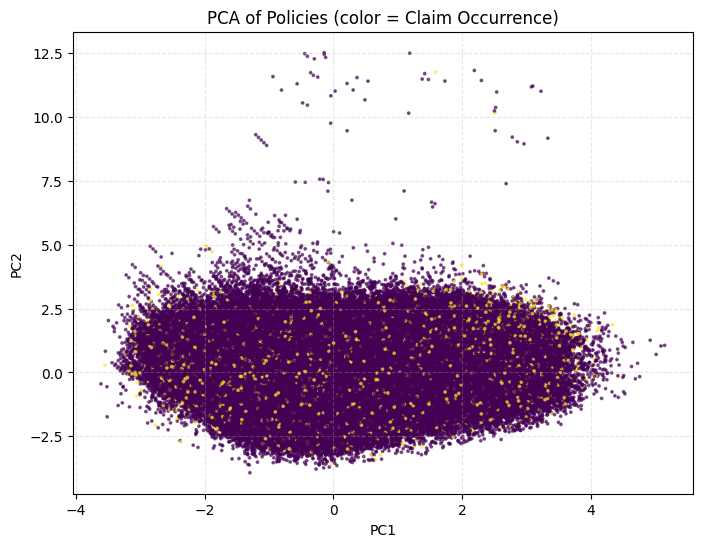

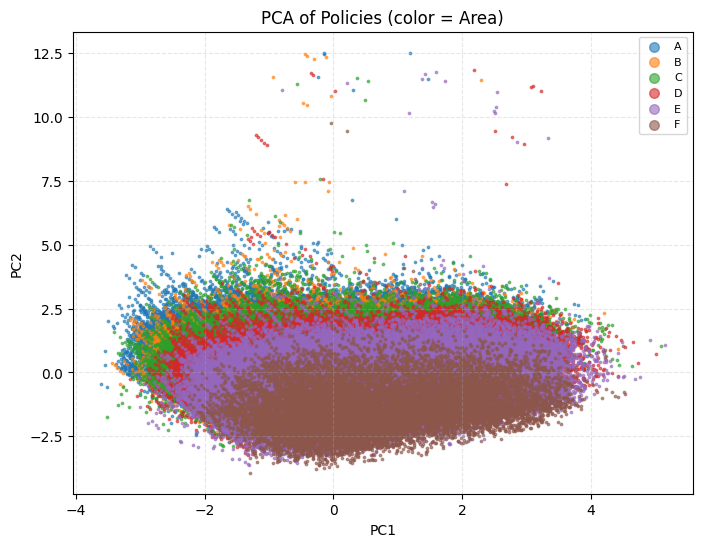

In [ ]:
# PCA
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance (2 components):", pca.explained_variance_ratio_.sum())

# Build a DataFrame for plotting
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Labels for coloring
pca_df["ClaimOccur"] = (df["ClaimNb"] > 0).astype(int) 
pca_df["Area"] = df["Area"]

# Visualization 1: PC1 vs PC2 colored by claim occurrence
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["ClaimOccur"],
    s=3,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Policies (color = Claim Occurrence)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# Visualization 2: PC1 vs PC2 colored by Area
plt.figure(figsize=(8, 6))
for area, group in pca_df.groupby("Area"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=3,
        alpha=0.6,
        label=area
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Policies (color = Area)")
plt.legend(markerscale=4, fontsize=8)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

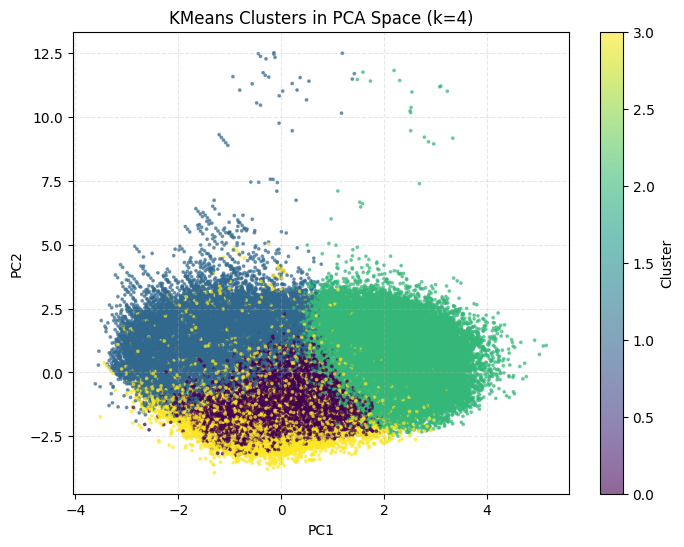

         n_policies  claim_frequency  mean_Exposure  mean_VehAge  \
cluster                                                            
0          170094.0         0.152552       0.253776     4.699113   
1          178141.0         0.069171       0.905038     8.812317   
2          124718.0         0.154530       0.394912     8.029114   
3           68463.0         0.106647       0.468816     6.469889   

         mean_DrivAge  mean_BonusMalus  mean_Density  
cluster                                               
0           48.831176        52.429092   2029.509806  
1           51.209278        52.105102    981.685025  
2           31.870644        83.570872   2310.123912  
3           47.220221        54.564553   2397.551846  


/var/folders/hd/92nbnfpd4rv8htp4cnmv91r40000gn/T/ipykernel_7007/3987376477.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_summary = df.groupby("cluster").apply(


In [32]:
# KMeans clustering on PCA
k = 4  # number of clusters
kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

# PCA for 2D visualization of clusters
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=3,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clusters in PCA Space (k={k})")
plt.grid(True, linestyle="--", alpha=0.3)
plt.colorbar(scatter, label="Cluster")
plt.show()

# ---------- Cluster-level risk summary ----------
# Claim frequency = total claims / total exposure
def claim_frequency(group):
    return group["ClaimNb"].sum() / group["Exposure"].sum()

cluster_summary = df.groupby("cluster").apply(
    lambda g: pd.Series({
        "n_policies": len(g),
        "claim_frequency": claim_frequency(g),
        "mean_Exposure": g["Exposure"].mean(),
        "mean_VehAge": g["VehAge"].mean(),
        "mean_DrivAge": g["DrivAge"].mean(),
        "mean_BonusMalus": g["BonusMalus"].mean(),
        "mean_Density": g["Density"].mean()
    })
).sort_index()

print(cluster_summary)

In [26]:
# KMeans clustering NO PCA
k = 4 
kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

# Attach cluster labels back to the original dataframe
df["cluster"] = clusters

# Inspect cluster centers (in standardized space)
print("Cluster centers (standardized feature space):")
centers = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
print(centers)

# Cluster-level risk summary
# Claim frequency = total claims / total exposure in each cluster
def claim_frequency(group):
    return group["ClaimNb"].sum() / group["Exposure"].sum()

cluster_summary = df.groupby("cluster").apply(
    lambda g: pd.Series({
        "n_policies":      len(g),
        "claim_frequency": claim_frequency(g),
        "mean_Exposure":   g["Exposure"].mean(),
        "mean_VehAge":     g["VehAge"].mean(),
        "mean_DrivAge":    g["DrivAge"].mean(),
        "mean_BonusMalus": g["BonusMalus"].mean(),
        "mean_Density":    g["Density"].mean()
    })
).sort_index()

print("\nCluster-level risk summary:")
print(cluster_summary)

Cluster centers (standardized feature space):
   Exposure  VehPower    VehAge   DrivAge  BonusMalus_log  Density_log
0 -0.752631 -0.307688 -0.415822  0.235695       -0.476704     0.130702
1  1.036275 -0.273095  0.312465  0.403595       -0.504682    -0.330184
2 -0.365098 -0.259392  0.174317 -0.964153        1.552097     0.237014
3 -0.162139  1.945219 -0.097937  0.120959       -0.330369     0.102675

Cluster-level risk summary:
         n_policies  claim_frequency  mean_Exposure  mean_VehAge  \
cluster                                                            
0          170094.0         0.152552       0.253776     4.699113   
1          178141.0         0.069171       0.905038     8.812317   
2          124718.0         0.154530       0.394912     8.029114   
3           68463.0         0.106647       0.468816     6.469889   

         mean_DrivAge  mean_BonusMalus  mean_Density  
cluster                                               
0           48.831176        52.429092   2029.50980

/var/folders/hd/92nbnfpd4rv8htp4cnmv91r40000gn/T/ipykernel_7007/130729588.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_summary = df.groupby("cluster").apply(


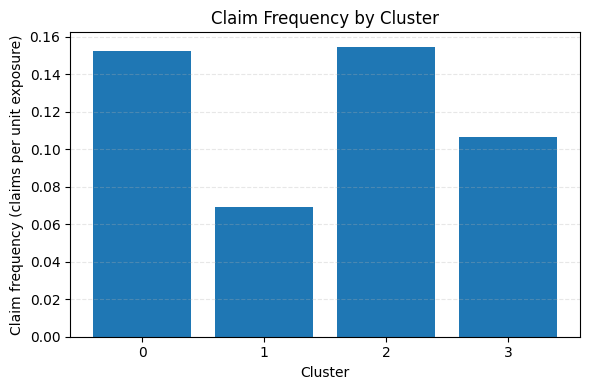

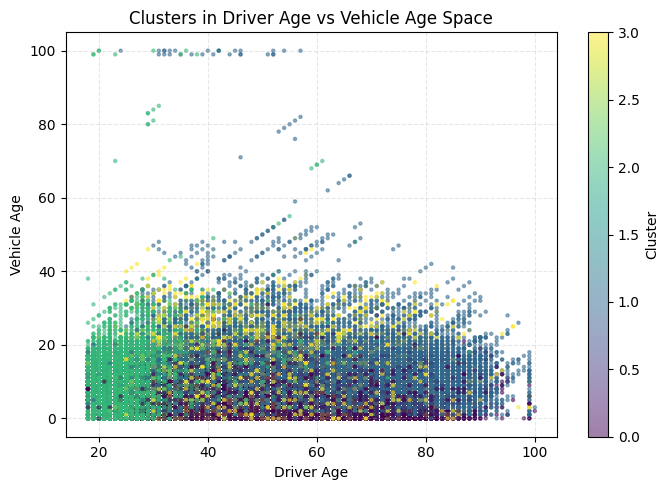

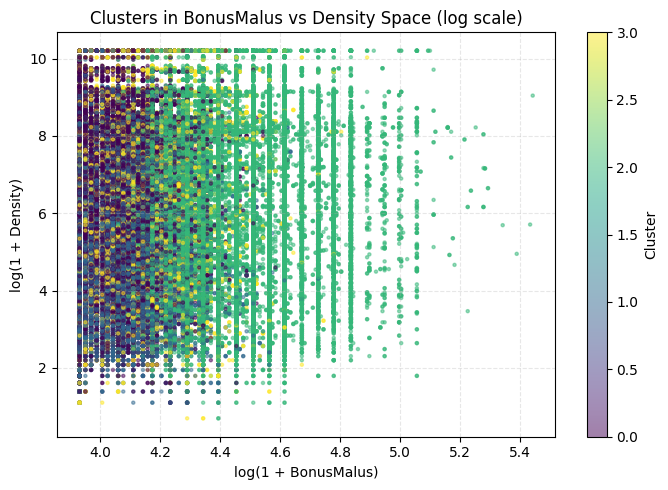

In [28]:
# Claim frequency by cluster
plt.figure(figsize=(6, 4))
x = np.arange(len(cluster_summary))
plt.bar(x, cluster_summary["claim_frequency"])
plt.xticks(x, cluster_summary.index)
plt.xlabel("Cluster")
plt.ylabel("Claim frequency (claims per unit exposure)")
plt.title("Claim Frequency by Cluster")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Driver age vs Vehicle age, colored by cluster
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df["DrivAge"],
    df["VehAge"],
    c=df["cluster"],
    s=5,
    alpha=0.5
)
plt.xlabel("Driver Age")
plt.ylabel("Vehicle Age")
plt.title("Clusters in Driver Age vs Vehicle Age Space")
plt.grid(linestyle="--", alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label("Cluster")
plt.tight_layout()
plt.show()

# BonusMalus vs Density, colored by cluster
df["BonusMalus_log"] = np.log1p(df["BonusMalus"])
df["Density_log"]    = np.log1p(df["Density"])

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df["BonusMalus_log"],
    df["Density_log"],
    c=df["cluster"],
    s=5,
    alpha=0.5
)
plt.xlabel("log(1 + BonusMalus)")
plt.ylabel("log(1 + Density)")
plt.title("Clusters in BonusMalus vs Density Space (log scale)")
plt.grid(linestyle="--", alpha=0.3)
cbar = plt.colorbar(scatter)
cbar.set_label("Cluster")
plt.tight_layout()
plt.show()
